# Sales Prediction using Python 

Project 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [75]:
data =pd.read_csv("Advertising.csv",encoding="ISO-8859-1")
data

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [18]:
data ={
    'TV': [230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.8,
           66.1, 214.7, 23.8, 97.5, 204.1, 195.4, 67.8, 281.4, 69.2, 147.3],
    'Radio': [37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.1, 2.6,
              5.8, 24.0, 35.1, 7.6, 32.9, 47.7, 36.6, 39.6, 20.5, 23.9],
    'Newspaper': [69.2, 45.1, 69.3, 58.5, 58.4, 75.0, 23.5, 11.6, 1.0, 21.2,
                  24.2, 4.0, 65.9, 7.2, 46.0, 52.9, 114.0, 55.8, 18.3, 19.1],
    'Sales': [22.1, 10.4, 9.3, 18.5, 12.9, 7.2, 11.8, 13.2, 4.8, 10.6,
              8.6, 17.4, 9.2, 9.7, 19.0, 22.4, 12.5, 24.4, 11.3, 14.6]
}

In [20]:
df = pd.DataFrame(data)

In [22]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


# Data Cleaning

In [26]:
df.isnull()

,TV,Radio,Newspaper,Sales
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [30]:
df.fillna

<bound method DataFrame.fillna of        TV  Radio  Newspaper  Sales
0   230.1   37.8       69.2   22.1
1    44.5   39.3       45.1   10.4
2    17.2   45.9       69.3    9.3
3   151.5   41.3       58.5   18.5
4   180.8   10.8       58.4   12.9
5     8.7   48.9       75.0    7.2
6    57.5   32.8       23.5   11.8
7   120.2   19.6       11.6   13.2
8     8.6    2.1        1.0    4.8
9   199.8    2.6       21.2   10.6
10   66.1    5.8       24.2    8.6
11  214.7   24.0        4.0   17.4
12   23.8   35.1       65.9    9.2
13   97.5    7.6        7.2    9.7
14  204.1   32.9       46.0   19.0
15  195.4   47.7       52.9   22.4
16   67.8   36.6      114.0   12.5
17  281.4   39.6       55.8   24.4
18   69.2   20.5       18.3   11.3
19  147.3   23.9       19.1   14.6>

In [32]:
df.dropna()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [40]:
import seaborn as sns

# Feature Selection

In [44]:
corr_matrix = df.corr()
corr_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.006860,-0.044222,0.862925
Radio,0.006860,1.000000,0.677822,0.429610
Newspaper,-0.044222,0.677822,1.000000,0.204532
Sales,0.862925,0.429610,0.204532,1.000000


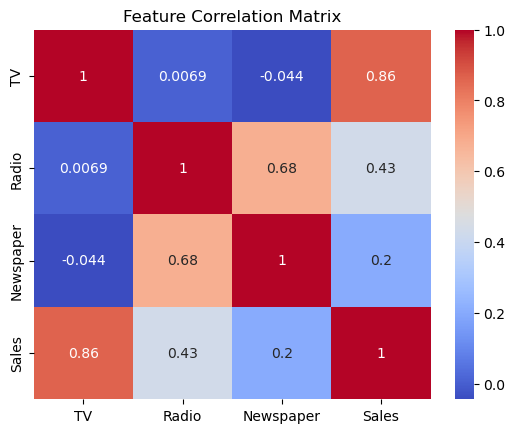

In [48]:
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# forecaste sales using regression or time series model

In [53]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
model = LinearRegression()

In [59]:
model.fit(X_train, y_train)

LinearRegression()

In [61]:
y_pred = model.predict(X_test)

In [63]:
print("\nModel Performance:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.3f}")
print(f"R-squared (R2 ): {r2_score(y_test, y_pred):.3f}")


Model Performance:
Mean Squared Error (MSE): 3.768
R-squared (R2 ): 0.876


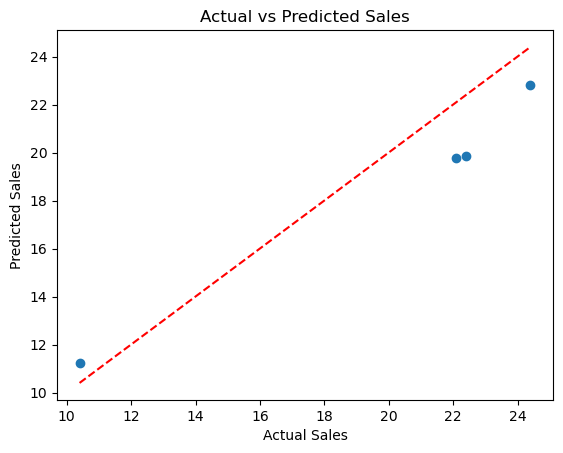

In [65]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()

# Impact/changes in sales outcome of advertising

In [67]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("\nAdvertising impact on sales:")
print(coefficients)


Advertising impact on sales:
     Feature  Coefficient
0         TV     0.049528
1      Radio     0.152785
2  Newspaper    -0.016878


# Insights for business marketing strategies

In [69]:
print("\nInsights:")
print("- TV and Radio advertising have positive coefficients, indicating positive impact on sales.")
print("- Newspaper advertising impact is smaller, could consider reallocating budget.")
print("- Increase spending on TV and Radio ads to maximize sales growth.")


Insights:
- TV and Radio advertising have positive coefficients, indicating positive impact on sales.
- Newspaper advertising impact is smaller, could consider reallocating budget.
- Increase spending on TV and Radio ads to maximize sales growth.
